In [ ]:
import ee
ee.Authenticate()
ee.Initialize(project='farmwise-classifier')



In [ ]:
!pip install earthengine-api
!pip install geemap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.8 MB/s eta 0:00:00


In [ ]:
!pip install earthengine-api geemap torch torchvision matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 93.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [ ]:
import ee
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

def get_sentinel_tile(lat, lon, size=64):
    point = ee.Geometry.Point([lon, lat])
    image = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
        .filterBounds(point) \
        .filterDate('2022-01-01', '2022-12-31') \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)) \
        .median() \
        .select(['B4', 'B3', 'B2'])

    vis_params = {
        'bands': ['B4', 'B3', 'B2'],
        'min': 0,
        'max': 3000,
        'dimensions': size,
        'format': 'png',
        'region': point.buffer(300).bounds()
    }

    url = image.getThumbURL(vis_params)

    # 🧠 Use requests instead of geemap
    response = requests.get(url)
    tile = Image.open(BytesIO(response.content))
    return tile


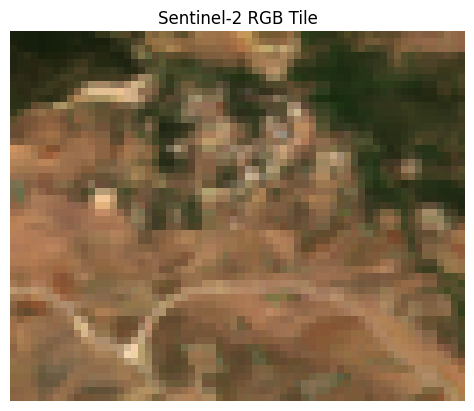

In [ ]:
tile = get_sentinel_tile(36.85284624116063, 9.005857457724204)
plt.imshow(tile)
plt.title("Sentinel-2 RGB Tile")
plt.axis('off')
plt.show()


In [ ]:
!pip install torch torchvision


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving EuroSAT.zip to EuroSAT.zip


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!cp EuroSAT.zip /content/drive/MyDrive/


In [ ]:
import zipfile
with zipfile.ZipFile("/content/drive/MyDrive/EuroSAT.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/EuroSAT")
print("✅ EuroSAT dataset unzipped!")

✅ EuroSAT dataset unzipped!


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 📦 Define preprocessing transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 📂 Load dataset
dataset = datasets.ImageFolder("/content/EuroSAT/2750", transform=transform)

# 🔀 Split: 80% train, 20% val
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 🧪 Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print("✅ Data ready! Classes:", dataset.classes)


✅ Data ready! Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import time

# ✅ Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ✅ Dataset prep
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder("/content/EuroSAT/2750", transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# Load ResNet50 from scratch (NO pretrained weights)
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ✅ Training loop
best_acc = 0.0
best_model_path = "/content/eurosat_resnet50_best.pth"
train_losses = []
val_accuracies = []

for epoch in range(100):  # 🔁 increase to 100+ if needed
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_losses.append(running_loss)

    # Validation
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    val_accuracies.append(acc)

    print(f"📅 Epoch {epoch+1} | Loss: {running_loss:.4f} | Val Acc: {acc*100:.2f}%")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), best_model_path)

print(f"\n✅ Best validation accuracy: {best_acc*100:.2f}%")


Using device: cuda
📅 Epoch 1 | Loss: 694.5334 | Val Acc: 70.78%
📅 Epoch 2 | Loss: 473.0323 | Val Acc: 76.00%
📅 Epoch 3 | Loss: 368.3923 | Val Acc: 80.35%


In [ ]:
# Save your model permanently (rename if you want)
torch.save(model.state_dict(), "/content/eurosat_resnet50_pretrained.pth")


In [ ]:
!cp /content/eurosat_resnet50_pretrained.pth /content/drive/MyDrive/


In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch
from torchvision import transforms

# Reload trained model (from scratch)
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)
model.load_state_dict(torch.load("/content/eurosat_resnet50_best.pth", map_location='cpu'))
model.eval()

# Labels
eurosat_labels = [
    'Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway',
    'Industrial', 'Pasture', 'Permanent Crop', 'Residential',
    'River', 'Sea/Lake'
]

# Preprocess the tile (after get_sentinel_tile())
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

input_tensor = transform(tile).unsqueeze(0)

# Predict
with torch.no_grad():
    outputs = model(input_tensor)
    pred_idx = torch.argmax(outputs, 1).item()
    predicted_label = eurosat_labels[pred_idx]

print(f"🧠 Predicted Land Class: **{predicted_label}**")


🧠 Predicted Land Class: **Permanent Crop**


In [ ]:
# 📥 Mount Google Drive first
from google.colab import drive
drive.mount('/content/drive')

# 📦 Reload model
import torchvision.models as models
import torch.nn as nn
import torch

model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)

model.load_state_dict(torch.load("/content/drive/MyDrive/eurosat_checkpoints/eurosat_resnet50_best.pth", map_location='cuda' if torch.cuda.is_available() else 'cpu'))
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("✅ Model loaded!")


Mounted at /content/drive
✅ Model loaded!


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 📂 Mount Drive first (if not mounted)
from google.colab import drive
drive.mount('/content/drive')

# 📂 Define transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ⚡ Correct path: where your 2750 folder is in Drive
dataset = datasets.ImageFolder("/content/drive/MyDrive/2750", transform=transform)

# 🔀 Split 80% train, 20% validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 🧪 DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
correct = 0
total = 0

# 🚀 Fast evaluation on a subset
with torch.no_grad():
    for i, (inputs, labels) in enumerate(val_loader):
        if i >= 15:  # ⬅️ Check only first 15 batches (~15 x 32 = 480 images)
            break
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"✅ Reloaded model fast validation accuracy: {accuracy*100:.2f}% (on partial data)")


✅ Reloaded model fast validation accuracy: 98.96% (on partial data)


In [ ]:
correct = 0
total = 0

# 🚀 Full evaluation on the entire validation set
with torch.no_grad():
    for inputs, labels in val_loader:  # No break this time!
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"✅ Full validation accuracy: {accuracy*100:.2f}%")


✅ Full validation accuracy: 98.96%
